In [1]:
import numpy as np
from matplotlib import pyplot as plt
import scipy.stats as stats
from pycircstat2.descriptive import circ_mean_and_r


plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.spines.top"] = False
plt.rcParams["font.size"] = 12
plt.rcParams["legend.frameon"] = False

In [22]:
lr = 0.01
a = 10
N = 500
N_i = 500
prop_shift = 0.0
hebb_k = 1.0
eta_k = 0.2
w_clip = True

def gaussian(x, mu, sigma):
    return np.exp(-(x - mu)**2/(2 * sigma**2)) * 1/(np.sqrt(2 * np.pi) * sigma)

def init_weights(N, N_i):

    vars_ef = np.random.lognormal(mean=2, sigma=0.6, size=N)
    vars_if = np.random.lognormal(mean=3, sigma=0.6, size=N_i)
    varss_ei = np.random.lognormal(mean=3, sigma=0.6, size=N)

    x = np.linspace(0, 180, N)
    matrix = np.zeros((N, N))
    for i in range(N):
        matrix[:, i] = stats.norm.pdf(x, x[i], vars_ef[i]) + stats.norm.pdf(x, x[i] + 180, vars_ef[i]) + stats.norm.pdf(x, x[i] - 180, vars_ef[i])
    w = matrix/N
    w /= np.sum(w, axis=0)

    x = np.linspace(0, 180, N_i)
    matrix = np.zeros((N, N_i))
    for i in range(N_i):
        matrix[:, i] = stats.norm.pdf(x, x[i], vars_if[i]) + stats.norm.pdf(x, x[i] + 180, vars_if[i]) + stats.norm.pdf(x, x[i] - 180, vars_if[i])
    w_if = matrix/N
    w_if /= np.sum(w_if, axis=0)

    x = np.linspace(0, 180, N)
    matrix = np.zeros((N_i, N))
    for i in range(N):
        matrix[:, i] = stats.norm.pdf(x, x[i], varss_ei[i]) + stats.norm.pdf(x, x[i] + 180, varss_ei[i]) + stats.norm.pdf(x, x[i] - 180, varss_ei[i])
    w_ei = matrix/N_i
    w_ei /= np.sum(w_ei, axis=0)

    return w, w_if, w_ei
    

def circular_gaussian(theta, amp=0.62, sigma=25, baseline=0):
    theta_y = np.linspace(0, 180, N)
    d = np.abs(theta - theta_y)
    d_plus = d + 180
    d_minus = d - 180
    y = amp * (np.exp(-d**2/(2 * sigma**2)) + np.exp(-d_plus**2/(2 * sigma**2)) + np.exp(-d_minus**2/(2 * sigma**2))) + baseline
    return y

def noise(w):
    return np.random.randn(*w.shape)  # random noise to simulate variability in plasticity

def normalize(x):
    return x / np.sum(x, axis=0, keepdims=True)  # normalize weights to sum to 1

def propensity(x):
    return np.tanh((a * x) + prop_shift)  # example propensity function

def circular_dist(x, y):
    return np.minimum(np.abs(x - y), 180 - np.abs(x - y))  # circular distance between two angles


def step(w, w_if, w_ei, I_cno=0):
    theta = np.random.uniform(0, 180)  # random phase
    r_f =  circular_gaussian(theta)# activity of the stimulus locked presynaptic population
    r_i =  np.clip(w_if.T @ r_f - I_cno, 0, np.inf)# activity of inhibitory population
    r_E =  np.clip(w.T @ r_f - w_ei.T @ r_i, 0, np.inf)  # activity of the single excitatory neuron of interest

    return r_f, r_i, r_E

def plasticity_rule(r_f, r_i, r_E, w, w_max=None):
    # Hebbian term
    hebbian_term = np.outer(r_f, r_E)

    # Update weights based on the plasticity rule
    dw = lr * propensity(w) * ((hebb_k * hebbian_term) - (eta_k*noise(w)))
    w_new = w + dw
    if w_clip:
        w_new = np.clip(w_new, 0, w_max)  # clip weights to be non-negative
    return w_new

def PO_estimate(w, w_if, w_ei, I_cno=0, method='argmax', min_r=0.05):
    n_theta = 100
    theta_list = np.linspace(0, 180, n_theta, endpoint=False)
    activity = np.zeros((N, n_theta))

    for theta_idx, theta in enumerate(theta_list):
        r_f = circular_gaussian(theta)
        r_i = np.clip(w_if.T @ r_f - I_cno, 0, np.inf)
        r_E = np.clip(w.T @ r_f - w_ei.T @ r_i, 0, np.inf)
        activity[:, theta_idx] = r_E

    if method == 'argmax':
        peak = activity.max(axis=1)
        return np.where(peak > 0, theta_list[np.argmax(activity, axis=1)], np.nan)  # return NaN if peak is below threshold
        
    elif method == 'circular_mean':
        alpha2 = 2 * np.deg2rad(theta_list)
        POs = np.full(N, np.nan)  # Initialize POs with NaN
        for i in range(N):
            if activity[i].sum() <= 1e-12: # silent: skip, avoids nan warning
                continue
            mu, r = circ_mean_and_r(alpha2, w=activity[i])
            if np.isnan(mu) or r < min_r: # untuned: no meaningful PO
                continue
            POs[i] = (np.rad2deg(mu / 2)) % 180  # halve back to [0, 180)
        return POs
    else:
        raise ValueError("Invalid method")
    
    return POs

def run_sim():

    n_steps = 300 + 28*30
    n_steps_per_norm = 30

    r_f_rec = []
    r_i_rec = []
    r_e_rec = []

    POs = []
    w,w_if, w_ei = init_weights(N, N_i)
    w_rec = [w]
    if w_clip:
        w_max = 1.5 * np.percentile(w, 99)  # set w_max to the 99th percentile of initial weights
    for t in range(n_steps):
        r_f, r_i, r_E = step(w, w_if, w_ei)
        w = plasticity_rule(r_f, r_i, r_E, w, w_max=w_max if w_clip else None)

        # r_f_rec.append(r_f); r_i_rec.append(r_i); r_e_rec.append(r_E)


        if (t + 1) % n_steps_per_norm == 0:
            w = normalize(w)  # normalize weights after each update
        w_rec.append(w)
        POs.append(PO_estimate(w, w_if, w_ei, method='circular_mean', min_r=0.05))

    return r_f_rec, r_i_rec, r_e_rec, w_rec, POs

def drift_metrics(POs, ref_angle=90):
    preferences = POs.T
    initial_preferences = preferences[:, 0]

    drift_mag = np.array([circular_dist(initial_preferences, preferences[:, t]) for t in range(preferences.shape[1])])
    drift_rate = np.array([circular_dist(preferences[:, t], preferences[:, t + 1]) for t in range(preferences.shape[1] - 1)])

    initial_dist = circular_dist(initial_preferences, ref_angle)
    distances = circular_dist(preferences, ref_angle)
    convergence = np.array([initial_dist - distances[:, t] for t in range(preferences.shape[1] - 1)])
    return drift_mag, drift_rate, convergence

In [23]:
r_f_rec, r_i_rec, r_e_rec, w_rec, POs = run_sim()


In [24]:

cell_idx = 249
incoming_weights = np.array(w_rec)[:, :, cell_idx]  # Extract the weights for the cell of interest

POs = np.array(POs)
POs_cell = POs[:, cell_idx]


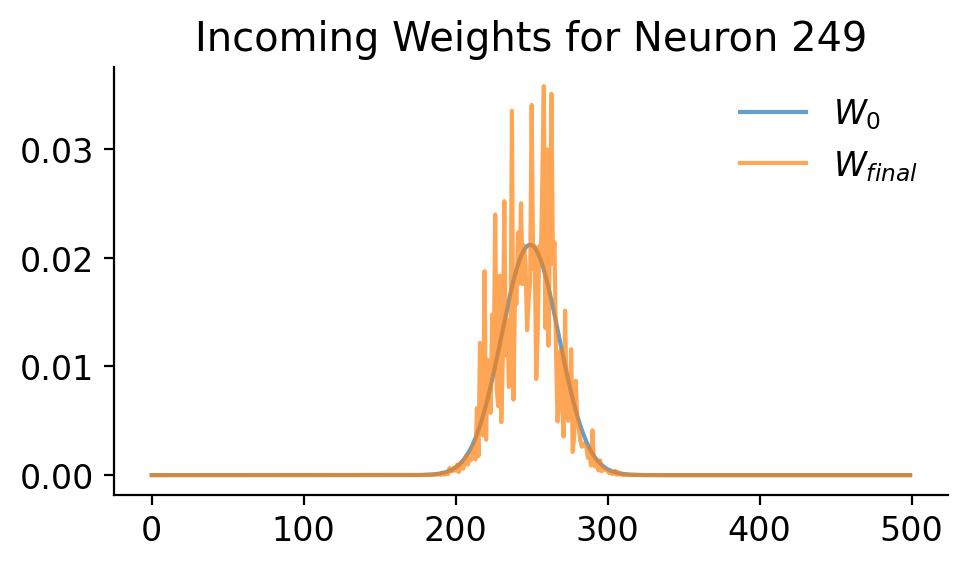

In [ ]:
# Plot the transition of the weight matrix for a single neuron over time
plt.figure(figsize=(5, 3), dpi=200)
plt.plot(incoming_weights[0], label=r'$W_0$', alpha=0.7)
plt.plot(incoming_weights[-1], label=r'$W_{final}$', alpha=0.7)
plt.legend()
plt.title(f'Incoming Weights for Neuron {cell_idx}')
plt.tight_layout()

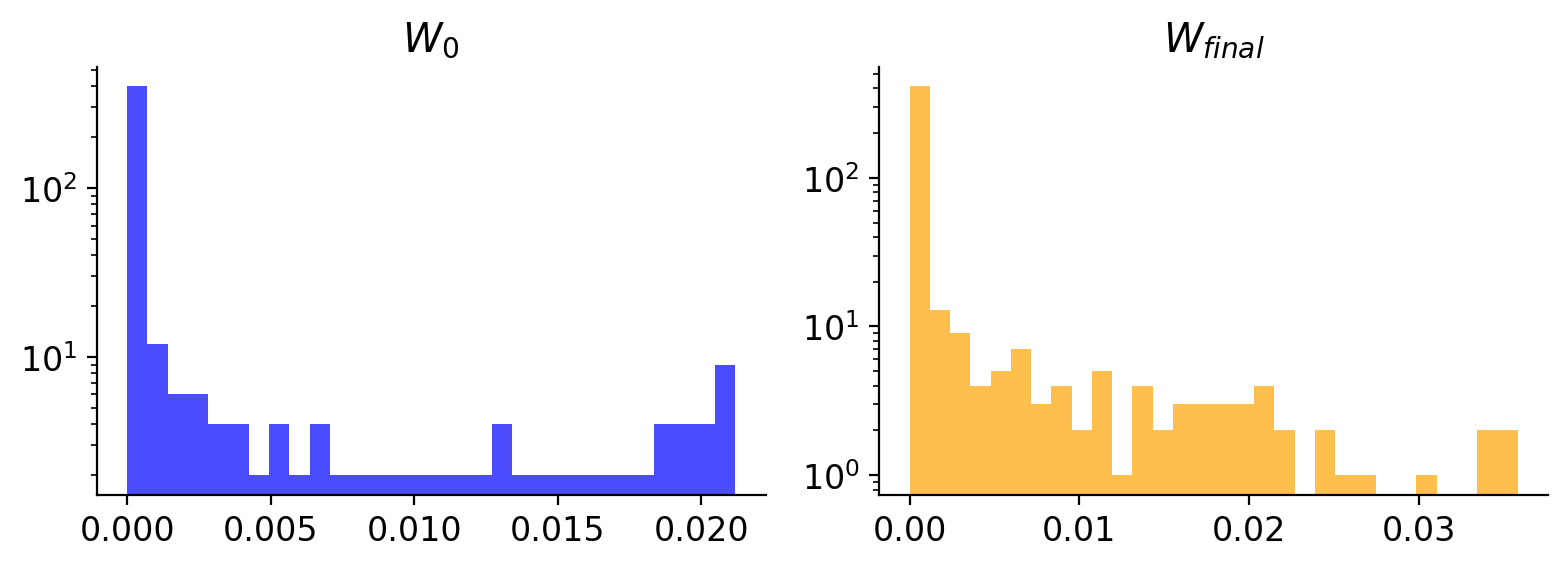

In [35]:
# Plot weights distribution at the beginning and end of the simulation
fig, axs = plt.subplots(1, 2, figsize=(8, 3), dpi=200)
axs[0].hist(incoming_weights[0], bins=30, color='blue', alpha=0.7)
axs[0].set_title(r'$W_0$')
axs[1].hist(incoming_weights[-1], bins=30, color='orange', alpha=0.7)
axs[1].set_title(r'$W_{final}$')
axs[0].set_yscale('log')
axs[1].set_yscale('log')    
fig.tight_layout()

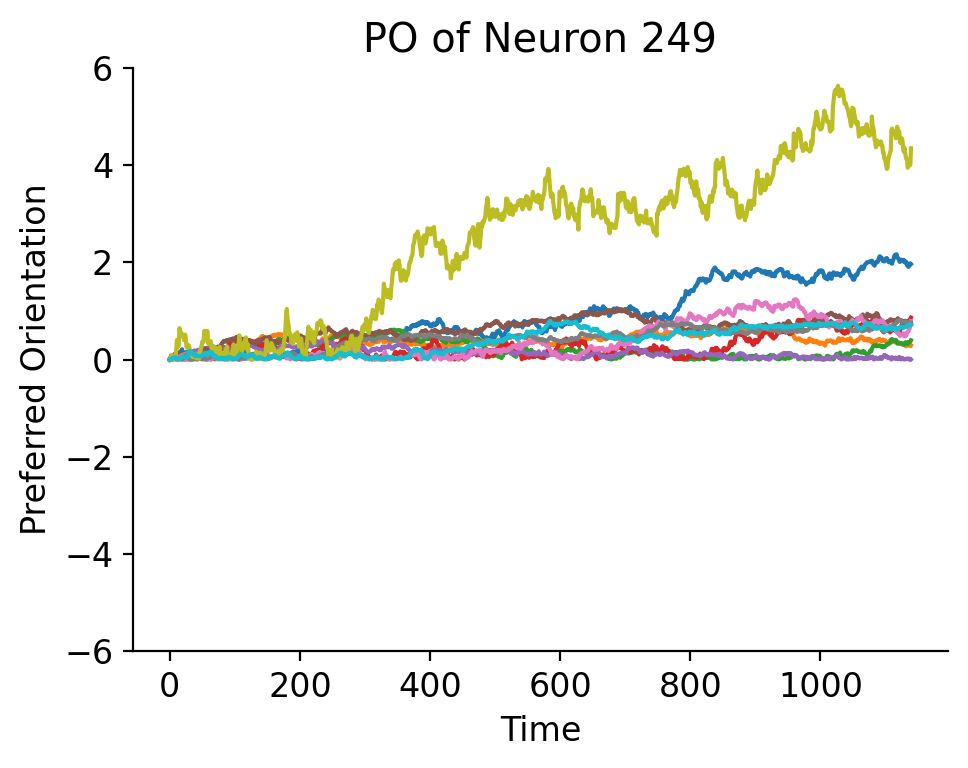

In [36]:
# Plot POs over time for the cell of interest
cell_idxs = np.arange(0, N, 50)  # Example: plot every 50th neuron
plt.figure(figsize=(5, 4), dpi=200)
for i in cell_idxs:
    plt.plot(circular_dist(POs[:, i], POs[0, i]), label=f'Neuron {i}')
plt.xlabel('Time')
plt.ylabel('Preferred Orientation')
plt.title(f'PO of Neuron {cell_idx}')
plt.ylim((-6, 6))
# plt.legend()


plt.tight_layout()
plt.show()

In [37]:
drift_mag, drift_rate, convergence = drift_metrics(POs, ref_angle=90)


(array([347., 101.,  28.,   9.,   5.,   3.,   0.,   0.,   2.,   0.,   1.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   1.,
          1.,   0.,   0.,   0.,   0.,   0.,   0.,   1.]),
 array([1.48655996e-04, 8.60293605e-02, 1.71910065e-01, 2.57790770e-01,
        3.43671474e-01, 4.29552179e-01, 5.15432883e-01, 6.01313588e-01,
        6.87194292e-01, 7.73074997e-01, 8.58955701e-01, 9.44836406e-01,
        1.03071711e+00, 1.11659782e+00, 1.20247852e+00, 1.28835922e+00,
        1.37423993e+00, 1.46012063e+00, 1.54600134e+00, 1.63188204e+00,
        1.71776275e+00, 1.80364345e+00, 1.88952416e+00, 1.97540486e+00,
        2.06128556e+00, 2.14716627e+00, 2.23304697e+00, 2.31892768e+00,
        2.40480838e+00, 2.49068909e+00, 2.57656979e+00]),
 <BarContainer object of 30 artists>)

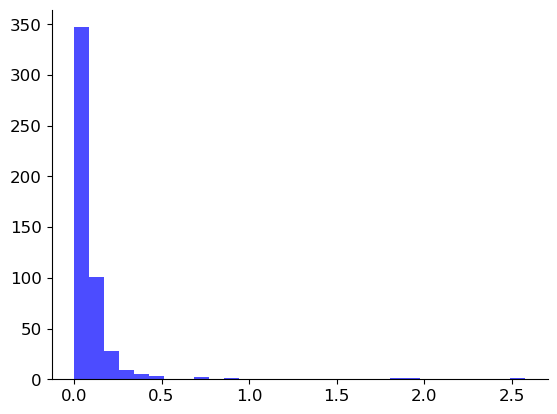

In [38]:
t = 10
plt.hist(drift_mag[t], bins=30, color='blue', alpha=0.7)

In [39]:
np.nanmean(drift_mag, axis=1)[::30]

array([0.        , 0.16419238, 0.22783196, 0.27718601, 0.30430743,
       0.37116051, 0.38880508, 0.40654918, 0.43118876, 0.46023307,
       0.50364186, 0.49674147, 0.51370969, 0.54020396, 0.55591187,
       0.58585125, 0.61189878, 0.62871913, 0.66210555, 0.68747923,
       0.70910841, 0.73305097, 0.73294937, 0.76175   , 0.76936899,
       0.77654388, 0.7989186 , 0.80181295, 0.82725945, 0.83678933,
       0.86658128, 0.88490712, 0.88267689, 0.89386267, 0.92266817,
       0.92420928, 0.94285706, 0.95194776])

(10.0, 38.0)

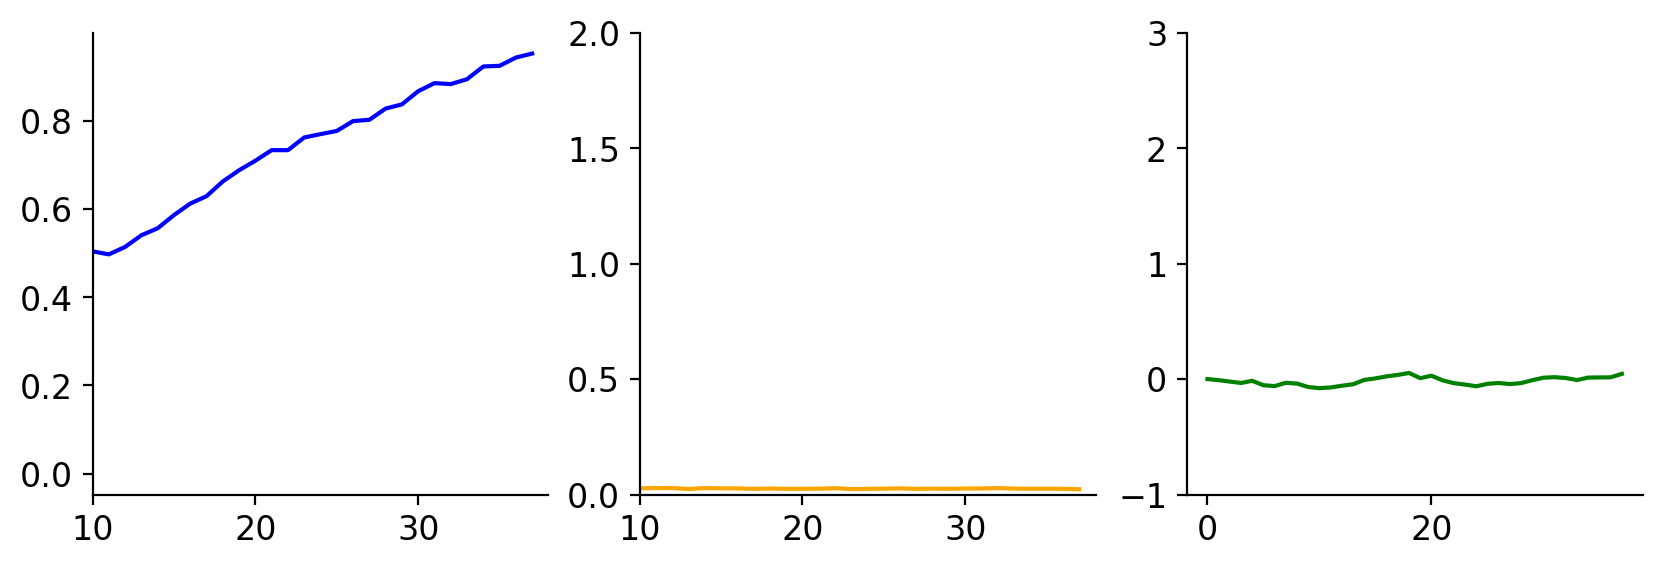

In [40]:
fig, axs = plt.subplots(1, 3, figsize=(10, 3), dpi=200)
axs[0].plot(np.nanmean(drift_mag, axis=1)[::30], label='Drift Magnitude', color='blue')
axs[1].plot(np.nanmean(drift_rate, axis=1)[::30], label='Drift Rate', color='orange')
axs[2].plot(np.nanmean(convergence, axis=1)[::30], label='Convergence', color='green')
axs[1].set_ylim(0, 2)
axs[2].set_ylim(-1, 3)

axs[0].set_xlim(10, 38)
axs[1].set_xlim(10, 38)

In [11]:
# Plot activity of the cell of interest over time
r_E = np.array(r_e_rec)[:, :]
r_I = np.array(r_i_rec)[:, :]
r_F = np.array(r_f_rec)[:, :]

time_idx = 0
fig, axs = plt.subplots(3, 1, figsize=(5, 4), dpi=200)
axs[0].plot(r_E[time_idx], '.', color='blue')
axs[0].set_xlabel('Time')
axs[0].set_ylabel('Activity')


axs[1].plot(r_I[time_idx], '.', color='red')
axs[1].set_xlabel('Time')
axs[1].set_ylabel('Activity')

axs[2].plot(r_F[time_idx], '.', color='green')
axs[2].set_xlabel('Time')
axs[2].set_ylabel('Activity')


IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed